### Simple Linear Regression Project
#### Modelling the linear relationship between Years of Experience and Salary dataset

#### Project Overview
<span style="font-size:13px;">
This project aims to predict an employee's salary based on their years of experience using the Simple Linear Regression algorithm. It demonstrates the complete machine learning workflow, including data loading, exploratory data analysis (EDA), model training, prediction, and performance evaluation. The project helps in understanding how a linear relationship between two variables can be used to make accurate predictions and builds a strong foundation for learning regression techniques.
</span>

#### Import Libraries
<span style="font-size:13px;">
The first step is to import the required Python libraries that will be used for data analysis, visualization, and machine learning.
</span>

In [27]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Model Evaluation
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

#### Load Dataset 
<span style="font-size:13px;">
The dataset contains information about employee experience and their corresponding salary.

We load the dataset using the Pandas library.
</span>

In [28]:
df = pd.read_csv('salary_data (2).csv')
df.head()

,YearsExperience,Salary
0,0.5,32438
1,0.6,29910
2,0.7,32881
3,0.9,36552
4,1.0,33009


#### Understanding the Dataset

<span style="font-size:13px;">
Before building a machine learning model, it is important to understand the structure of the data.
</span>

In [29]:
df.shape

(100, 2)

<span style="font-size:13px;">The dataset contains 100 rows and 2 columns.</span>

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  100 non-null    float64
 1   Salary           100 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 1.7 KB


In [31]:
df.describe()

,YearsExperience,Salary
count,100.000000,100.00000
mean,7.393000,70488.23000
std,4.224083,23880.09967
min,0.500000,29910.00000
25%,3.700000,51400.25000
50%,7.350000,70604.00000
75%,11.100000,89866.75000
max,14.900000,110495.00000


In [32]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [33]:
df.duplicated().sum()

np.int64(0)

#### Exploratory Data Analysis

<span style="font-size:13px;">EDA helps us understand the distribution of data and identify patterns before training the model.</span>

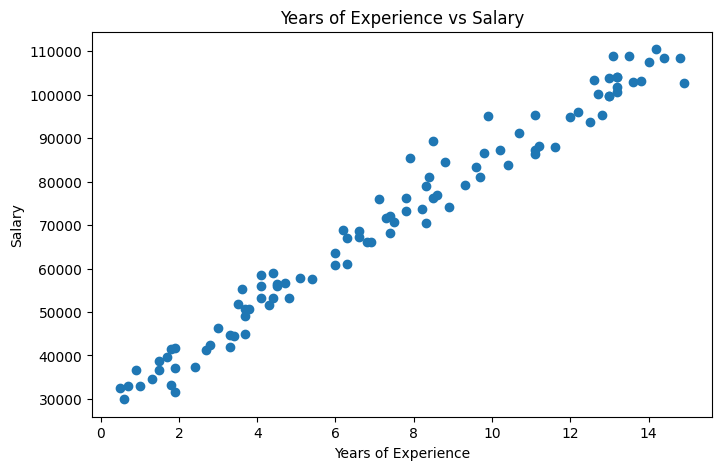

In [34]:
plt.figure(figsize=(8,5))
plt.scatter(df['YearsExperience'],df['Salary'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Years of Experience vs Salary')
plt.show()

#### Observation
<span style="font-size:13px;">
The scatter plot indicates a strong positive linear relationship between years of experience and salary.

This suggests that Simple Linear Regression is an appropriate algorithm for this problem.
</span>

In [35]:
df.corr()

,YearsExperience,Salary
YearsExperience,1.00000,0.98649
Salary,0.98649,1.00000


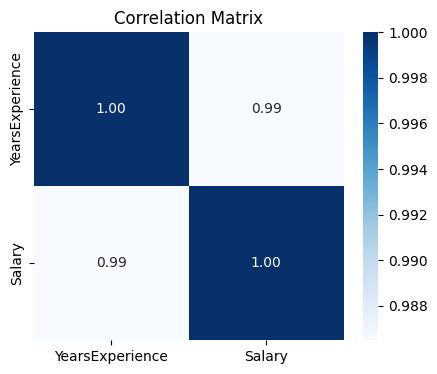

In [63]:
plt.figure(figsize=(5,4))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

#### Preparing the Data
<span style="font-size:13px;">
Machine learning models require separating the independent variable (feature) and dependent variable (target).
</span>

In [37]:
x = df[['YearsExperience']]
y = df['Salary']

#### Train-Test Split
<span style="font-size:13px;">
To evaluate the performance of the machine learning model on unseen data, the dataset is divided into training and testing sets. The model learns patterns from the training data and its performance is evaluated using the testing data. This helps determine how well the model generalizes to new data.
</span>

In [38]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

#### Building the Simple Linear Regression Model
<span style="font-size:13px;">
After preparing the data, the next step is to create and train the Simple Linear Regression model. During training, the algorithm learns the relationship between years of experience and salary by finding the best-fit regression line using the Ordinary Least Squares (OLS) method.
</span>

In [39]:
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Making Predictions
<span style="font-size:13px;">
Once the model has been trained, it can predict salaries for employees based on their years of experience. These predictions are then compared with the actual salary values to evaluate the model's performance.
</span>

In [42]:
y_pred = model.predict(x_test)

#### Model slope and intercept term
<span style="font-size:13px;">
The model slope is given by model.coef_ and model intercept term is given by model.intercept_.
</span>

In [64]:
# Compute model slope and intercept
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 5648.478781896646
Intercept: 28909.517802770824


##### So, our fitted regression line is 

##### y = 5648.4787819 * x - 28909.517802770824 

##### That is our linear model.

### Model Evaluation
<span style="font-size:13px;">
Model evaluation helps determine how accurately the regression model predicts salaries. Various evaluation metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score are used to measure prediction accuracy and overall model performance.
</span>

In [43]:
print("MAE :", mean_absolute_error(y_test, y_pred))

print("MSE :", mean_squared_error(y_test, y_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score :", r2_score(y_test, y_pred))

MAE : 3065.3449950647328
MSE : 13708488.369107794
RMSE : 3702.4975852939856
R2 Score : 0.9718151123476131


### Predicting Salary for New Employees
<span style="font-size:13px;">
After training the Simple Linear Regression model, we can use it to predict the salary of employees based on their years of experience. The model takes the years of experience as input and estimates the corresponding salary using the learned linear relationship.
</span>

In [61]:
new_employee = pd.DataFrame({
    "YearsExperience": [6.5]
})

predicted_salary = model.predict(new_employee)

print(f"Predicted Salary: {predicted_salary[0]:.2f}")

Predicted Salary: 65624.63


#### Plotting Regression line

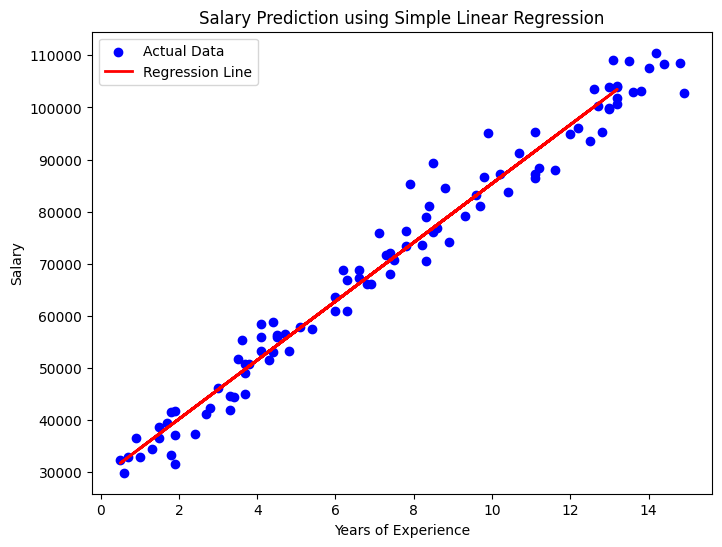

In [62]:
# Plot the original data points
plt.figure(figsize=(8,6))

plt.scatter(df["YearsExperience"],
            df["Salary"],
            color="blue",
            label="Actual Data")

# Plot the regression line
plt.plot(x_test,
         y_pred,
         color="red",
         linewidth=2,
         label="Regression Line")

# Labels and title
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary Prediction using Simple Linear Regression")

# Display legend
plt.legend()

# Show the graph
plt.show()